# <span style="color:rgb(160,0,86)">Modelle für zufällige Ereignisse mit Python</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie wissen was eine **Zufallsvariable** ist und verstehen den Unterschied zwischen der **Wahrscheinlichkeitsverteilung** und der Häufigkeitsverteilung.
- Sie kennen das Python Module *scipy*.
- Sie können den **Erwartungswert** und die **Standardabweichung** einer Zufallsvariablen mit Python berechnen.
- Sie können mit Hilfe der kumulativen Wahrscheinlichkeitsverteilung mit Python **Wahrscheinlichkeiten** berechnen.  
- Sie kennen die wichtigsten **diskreten** und **stetigen** Verteilungen.  

***

### <span style="color:rgb(160,0,86)">Warum brauchen wir in der Statistik mathematische Modell für Zufall?</span>

**Daten** und **Zufallsprozesse** sind eng miteinander verbunden, weil Daten oft als Beobachtungen von zufälligen Vorgängen betrachtet werden.    
- Ein **Zufallsvariable** $X$ beschreibt die möglichen Werte eines Zufallsexperiments (z.B. die Körpergrösse einer zufällig gewählten Person). Wenn wir Messungen durchführen, erhalten wir konkrete Werte $x$, die als Realisierungen der Zufallsvariable $X$ gelten.
- Die zugrunde liegende **Wahrscheinlichkeitsverteilung** einer Zufallsvariablen hilft, die Struktur der Daten zu verstehen. Statistische Modelle nutzen diese Verteilungen, um Vorhersagen oder Schlussfolgerungen zu ermöglichen.
- Aus Stichprobendaten werden Parameter geschätzt, um Rückschlüsse auf die zugrunde liegende Zufallsvariable und deren Verteilung zu ziehen.

Zusammenfassend sind **Zufallsvariablen** mathematische **Modelle** für die Prozesse, die **Daten erzeugen**. Daten wiederum liefern beobachtbare Werte, die helfen, die zugrunde liegenden Wahrscheinlichkeitsverteilungen zu verstehen und in der Statistik zu nutzen.

#### <span style="color:rgb(160,0,86)">Beispiele:</span>

Wenn wir **mehrmals einen Würfel werfen**, erzeugen wir Daten. Wir können zählen, wie oft jede Zahl erscheint und die relative Häufigkeit für jede Zahl bestimmen:


In [127]:
import numpy as np

[np.random.randint(1,7) for _ in range(20)]

[2, 2, 2, 6, 1, 3, 2, 5, 3, 3, 1, 4, 5, 3, 2, 3, 2, 3, 4, 2]

In [129]:
anzWürfe = 1000000
würfe = np.array([np.random.randint(1,7) for _ in range(anzWürfe)])
werte, absH = np.unique(würfe,return_counts=True)
relH = absH/anzWürfe
for i in werte:
    print("relative Häufigkeit der Augenzahl",i,":",relH[i-1])

relative Häufigkeit der Augenzahl 1 : 0.166423
relative Häufigkeit der Augenzahl 2 : 0.166986
relative Häufigkeit der Augenzahl 3 : 0.166355
relative Häufigkeit der Augenzahl 4 : 0.166348
relative Häufigkeit der Augenzahl 5 : 0.166923
relative Häufigkeit der Augenzahl 6 : 0.166965


Wenn wir davon ausgehen, dass wir einen **fairen Würfel** werfen, können wir dieses Zufallsexperiment mit einer **Zufallsvariablen** modelieren:
- Das Zufallsexperiment hat sechs mögliche Ergebnisse, die Augenzahlen *Eins*, *Zwei*, *Drei*, *Vier*, *Fünf* und *Sechs*.
- Eine Zufallsvariable $X$ ordnet nun all diesen Ergebnissen **Zahlenwerte** zu:
$$\begin{align*}&X(\textit{Eins})=1\\&X(\textit{Zwei})=2\\&X(\textit{Drei})=3\\&X(\textit{Vier})=4\\&X(\textit{Fünf})=5\\&X(\textit{Sechs})=6\end{align*}$$
- Weil wir von einem fairen Würfel ausgehen, können wir die relativen Häufigkeiten wegen der Symmetrie vorgeben. Wenn alle Augenzahlen gleich gewichtet werden, verteilt sich die $100$\% Summenhäufigkeit gleichmässig auf alle Zahlenwerte: $$\begin{array}{c|cccccc}x&1&2&3&4&5&6\\ \hline P(X=x)&16.\overline{6}\%&16.\overline{6}\%&16.\overline{6}\%&16.\overline{6}\%&16.\overline{6}\%&16.\overline{6}\%\end{array}$$ Die zugeordneten Werte $16.\overline{6}\%$ heissen **Wahrscheinlichkeiten**, sie werden aus dem gegebenen Modell mathematische berechnet und die gesamte Zuordung $P$ bezeichnen wir als **Wahrscheinlichkeitsverteilung**.<br>
Genau so, wie wir die Summenhäufigkeiten berechnet haben, können wir nun auch für diese Wahrscheinlichkeiten die **kumulative Wahrscheinlichkeitsverteiliung** angeben: $$\begin{array}{c|cccccc}x&1&2&3&4&5&6\\ \hline P(X\leqslant x)&16.\overline{6}\%&33.\overline{3}\%&50\%&66.\overline{6}\%&83.\overline{3}\% &100\%\end{array}$$ <br> Mit diesen Verteilungen können wir auch angeben, wie gross zum Beispiel die Wahrscheinlichkeit ist, dass wir eine Zahl zwischen 2 und 5 würfeln:
$$P(2<X<5) = P(X=3) + P(X=4) = 16.\overline{6}\% + 16.\overline{6}\% = 33.\overline{3}\%$$
oder mit den kumulativen Wahrscheinlichkeiten
$$P(2<X<5) = P(X\leqslant 4) - P(X\leqslant 2) = 66.\overline{6}\% - 33.\overline{3}\% = 33.\overline{3}\%\;.$$
- Aus den Daten haben wir die ***mittlere Lage*** und die ***Streuung*** berechnet. Diese Masse können wir auch im Modell bestimmen. Dem arithmetischen Mittel für die Lage entspricht der sogenannte **Erwartungswert** $\mu$ der Zufallsvariablen $X$
$$ \begin{align*}\mu &= P(X=1)\cdot 1 + P(X=2)\cdot 2 + \ldots + P(X=6)\cdot 6 \\
&=\frac{1}{6}\cdot 1 +\frac{1}{6}\cdot 2 + \frac{1}{6}\cdot 3 + \frac{1}{6}\cdot 4 + \frac{1}{6}\cdot 5 + \frac{1}{6}\cdot 6  = 3.5\end{align*}$$  
und der mittleren Quadratischen Abweichung entspricht die sogenannte **Varianz** $\sigma^2$ der Zufallsvariablen $X$
$$ \begin{align*}\sigma^2 &= P(X=1)\cdot (1-\mu)^2 + P(X=2)\cdot (2-\mu)^2 + \ldots + P(X=6)\cdot (6-\mu)^2 \\
&=\frac{1}{6}\cdot (1-3.5)^2 +\frac{1}{6}\cdot (2-3.5)^2 + \ldots + \frac{1}{6}\cdot (6-3.5)^2  = 2.91\overline{6}\end{align*}$$ beziehungsweise die **Standardabweichung** $$\sigma = \sqrt{2.91\overline{6}} = 1.7078\dots\;.$$

In den *Würfeldaten* **würfe** oben können wir die **Lage und Streuung** berechnen: 

In [130]:
mittel = sum(würfe)/anzWürfe
MQD = sum((würfe-mittel)**2)/anzWürfe
std = np.sqrt(MQD) 

print("arithmetisches Mittel:",mittel)
print("MQD:",MQD)
print("Standardabweichung:",std)

arithmetisches Mittel: 3.501257
MQD: 2.9181444199395905
Standardabweichung: 1.7082577147314717


Wir erkennen, dass die **empirischen Kennzahlen** aus den Daten mit den **theoretischen Kennzahlen** der Zufallsvariablen $\,X\,$ für einen fairen Würfel gut übereinstimmt. 

Die Funktion **np.random.randint()** scheint in der Tat <span style="color:rgb(160,0,86)">**einen fairen Würfel zu simulieren**</span>!

- Auch die $p$-**Quantile** können wir bei Zufallsvariablen $X$ aus der kumulativen Wahrscheinlichkeitsverteilung bestimmen. Das $p$-Quatil $x_p$ ist die Zahl mit der Eigenschaft $$P(X\leqslant x_p)\geqslant p \quad\text{ und }\quad P(X\geqslant x_p)\geqslant 1-p\;.$$
Also zum Beispiel ist beim Würfel das 75\%-Quantil die Augenzahl 5, weil
$$P(X\leqslant 5)= 83.\overline{3}\%\geqslant 75\% \quad\text{ und }\quad P(X\geqslant 5) = 100\%-P(X<5) =33.\overline{3}\% \geqslant 25\%\;.$$

***

### <span style="color:rgb(160,0,86)">Welche mathematischen Modelle für Zufallsprozesse gibt es?</span>

In Python haben wir mit dem **Modul** ***SciPy*** (**Scientific Python**) sämtliche wichtigen Wahrscheinlichkeitsverteilungen für Zufallsvariablen zur Verfügung.

Das ermöglicht uns in der Statistik, ohne vertieftes Studium der mathematischen Hintergründe, mit all diesen Wahrscheinlichkeitsverteilungen problemlos zu rechnen. 

- Zuerst müssen wir die **gewünschte Verteilung** für die Zufallsvariable **laden**: $$\texttt{from scipy.stats import NAME}$$
- Dann können wir die **Zufallsvariable** mit den Cumulative Distribution FunctionCumulative Distribution Functiongewünschten Parameteren **definieren**: $$\texttt{X = NAME(parameter\;=\;,...)}$$

Grundsätzlich brauchen wir die folgenden Funktionen und Methoden:

- Mit **rvs( )** für ***Radom Variable sample*** können wir zufällige Werte $\,\pmb{x}\,$ aus der Verteilung einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ generieren: $$\texttt{X.rvs()}$$
- Mit **pmf( )** für ***Probability Mass Function*** können wir die Wahrscheinlichkeit $\,\pmb{P(X=x)}\,$ für ein Ergebnis $\,\pmb{x}\,$ einer <span style="color:rgb(255,0,0)">***diskreten***</span> Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.pmf(x)}$$
- Mit **pdf( )** für ***Probability Density Function*** können wir die Wahrscheinlichkeitsdichte für <span style="color:rgb(255,0,0)">***stetige***</span> Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.pdf(x)}$$
- Mit **cdf( )** für ***Cumulative Distribution Function*** können wir die Wahrscheinlichkeit $\,\pmb{P(X\leqslant x)}\,$ für ein Ergebnis $\,\pmb{x}\,$ einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.cdf(x)}$$
- Mit **ppf( )** für ***Percent Point Function*** können wir das $\,\pmb{p}\,$**-Quantil** einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.ppf(p)}$$
- Mit **mean( )** können wir den **Erwartungswert** einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.mean()}$$
- Mit **var( )** können wir die **Varianz** einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.var()}$$
- Mit **std( )** können wir die **Standardabweichung** einer ***diskreten*** oder ***stetigen*** Zufallsvariablen $\,X\,$ ausgeben: $$\texttt{X.std()}$$

Auf der Seite https://docs.scipy.org/doc/scipy/reference/stats.html finden wir die verschiedenen Verteilungen von Zufallsvariablen, die **SciPy** zur Verfüngung stellt.

### <span style="color:rgb(160,0,86)">Die diskrete uniforme Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus der endlichen Menge $\{\texttt{low},\texttt{low}+1,\ldots,\texttt{high}-1\}$ hat eine **diskrere uniforme Verteilung**, wenn all diese Werte $x$ gleich wahrscheinlich sind: $$P(X=x)=\frac{1}{\texttt{high}-\texttt{low}}$$
- Wenn eine Zufallsvariable $\,\pmb{X}\,$ **diskret uniform** verteilt ist, schreiben wir $$X\sim \mathsf{dUni}(\text{low},\text{high})\;.$$
- In **SciPy** heisst diese Zufallsvariable **randint( )** und sie hat die zwei Parameter <tt>low</tt> und <tt>high</tt>.
- ***Zum Beispiel*** ein Wurf mit einem fairen Würfel.

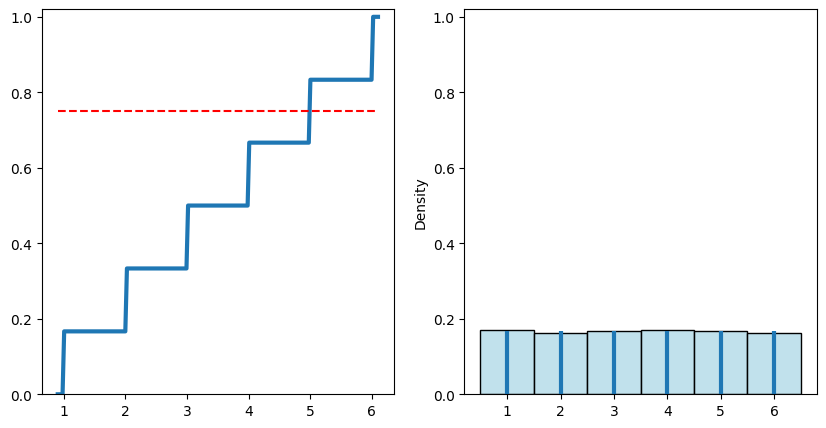

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import randint

#Zufallsvariable definieren
X = randint(low=1,high=7)

#Cumulative Distribution Function
x = np.linspace(0.9,6.1,200)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.arange(1,7))

#5000 zufällige Werte ziehen:
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,0.9,6.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(0.5,7.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.arange(1,7),0,X_pmf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [6]:
X.ppf(0.75)

5.0

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [7]:
X.mean()

3.5

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [8]:
X.var()

2.9166666666666665

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [9]:
X.std()

1.707825127659933

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [10]:
# Mit pmf:
X.pmf(3) + X.pmf(4)

0.3333333333333333

In [11]:
# Mit cdf:
X.cdf(4) - X.cdf(2)

0.3333333333333333

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>
Definieren Sie eine Zufallsvariable $X$, die auf den Werten $2,3,4,5,6,7,8,9$ diskret uniform verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie die Wahrscheinlichkeit $P(3.5<X\leqslant 6)$.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Suchen Sie typische Beispiele für Zufallsvariablen, die diskret uniform verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit diskreter uniformer Verteilung** auf den Werten 2, 3, 4, 5, 6, 7, 8 und 9:

In [1]:
from scipy.stats import randint

X = randint(low=2,high=10)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***: 

In [10]:
import numpy as np

X_pmf = X.pmf(np.arange(2,10))
X_cdf = X.cdf(np.linspace(0.9,10.1,300))

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

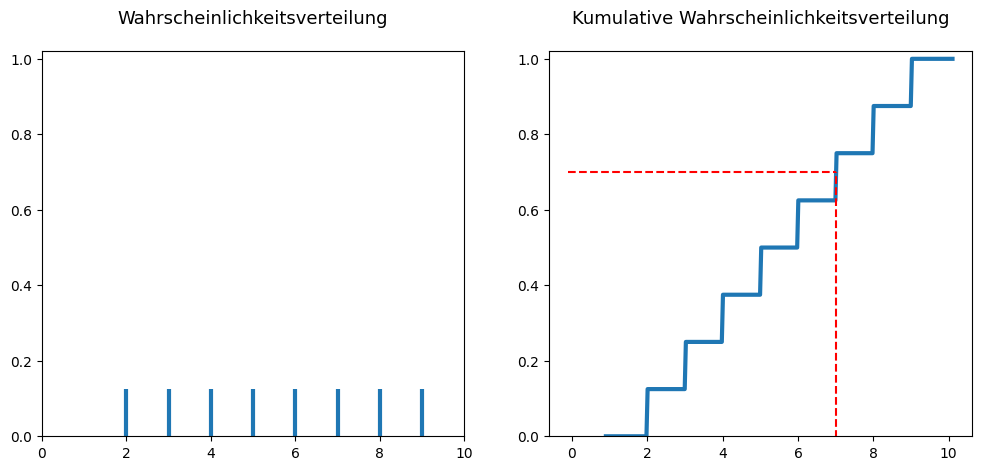

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.arange(2,10),0,X_pmf,lw=3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.xlim(0,10)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(0.9,10.1,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,7,color="red",linestyle="dashed")
ax2 = plt.vlines(7,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie die Wahrscheinlichkeit $P(3.5<X\leqslant 6)$.

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir: 

In [12]:
X.cdf(6) - X.cdf(3.5)

0.375

Mit der ***Wahrscheinlichkeitsverteilung*** finden wir:

In [13]:
X.pmf(4) + X.pmf(5) + X.pmf(6)

0.375

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Von **Hand** finden wir den **Erwartungswert**  
$$\mu = \frac{1}{8}\cdot 2 + \frac{1}{8}\cdot 3 + \frac{1}{8}\cdot 4 + \frac{1}{8}\cdot 5 + \frac{1}{8}\cdot 6 + \frac{1}{8}\cdot 7 + \frac{1}{8}\cdot 8 + \frac{1}{8}\cdot 9 = 5.5$$

Mit der Methode **mean( )** finden wir direkt

In [14]:
X.mean()

5.5

Von **Hand** finden wir die **Varianz**

$$\sigma^2 = \frac{1}{8}\cdot (2-5.5)^2 + \frac{1}{8}\cdot (3-5.5)^2 + \cdots + \frac{1}{8}\cdot (9-5.5)^2 = 5.25$$
und dann die **Standardabweichung** 
$$\sigma =  \sqrt{5.25} = 2.2912878474779\ldots\;.$$

Mit der Methode **var( )** finden wir direkt

In [15]:
X.std()

2.29128784747792

Von **Hand** finden wir **das 70\%-Quantil** mit der kumulativen Wahrscheinlichkeitsverteilung
$$\begin{array}{c|cccccccc}x&2&3&4&5&6&7&8&9\\ \hline 
P(X\leqslant x)& 
12.5\%&
25.0\%&
37.5\%&
50.0\%&
62.5\%&
75.0\%&
87.5\%&
100\%\end{array}$$ 
Wir müssen den Wert suchen, der zum ersten mal die kumulative Wahrscheinlichkeit von 70\% übersteigt:
$$P(X\leqslant 7)= 75\%\geqslant 70\% \quad\text{ und }\quad P(X\geqslant 7) = 100\%-62.5\% =37.5\% \geqslant 30\%\;.$$

Mit der Methode **ppf( )** finden wir direkt

In [16]:
X.ppf(0.7)

7.0

- Suchen Sie typische Beispiele für Zufallsvariablen, die diskret uniform verteilt sind.

#### Beispiele
- Würfeln mit einem fairen Würfel 
- Ziehen einer zufälligen Spielkarte
- Zufällige Auswahl einer Person aus einer Gruppe
- Lotto-Ziehung ohne Berücksichtigung der Reihenfolge
- Zufällige Auswahl einer Zahl aus einer Menge
- Drehen eines fairen Glücksrads mit gleich grossen Sektoren
- Zufällige Wahl einer Antwort auf eine Multiple-Choice-Frage
- Hashing in Datenstrukturen
- Zufällige Passwort- oder Token-Generierung
- Schlüsselgenerierung für One-Time-Pad in der Kryptografie

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Bernoulli Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus der Menge $\{0,1\}$ hat eine **Bernoulli Verteilung** mit: $$P(X=1)=p \;\,\text{ und }\,\; P(X=0)=1-p$$
- Wenn eine *diskrete* Zufallsvariable $X$ **Bernoulli** verteilt ist, schreiben wir $$X\sim \mathsf{Ber}(p)\;.$$
- In **SciPy** heisst diese Zufallsvariable **bernoulli( )** und sie hat einen Parameter <tt>p</tt>.
- ***Zum Beispiel*** ein Wurf mit einer gefälschten Münze.

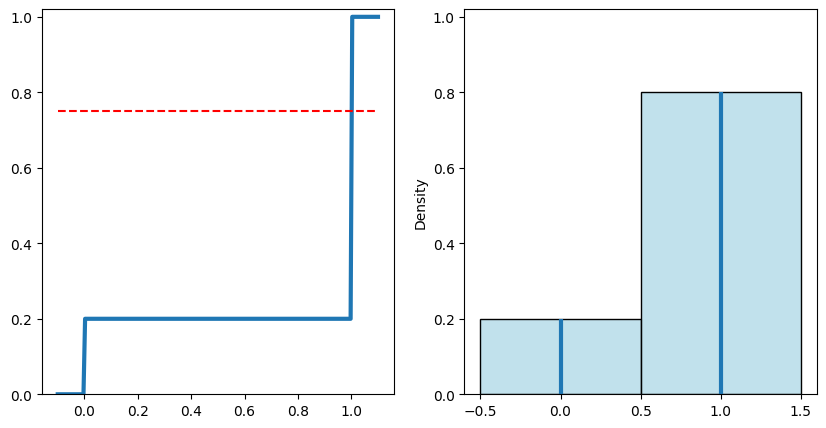

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import bernoulli

#Zufallsvariable definieren
X = bernoulli(p=0.8)

#Cumulative Distribution Function
x = np.linspace(-0.1,1.1,200)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.array([0,1]))

#5000 zufällige Werte ziehen:
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,1.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(-0.5,2.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.array([0,1]),0,X_pmf,lw=3)
ax2 = plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [19]:
X.ppf(0.75)

1.0

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [20]:
X.mean()

0.8

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [21]:
X.var()

0.15999999999999998

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [22]:
X.std()

0.39999999999999997

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>
Definieren Sie eine Zufallsvariable $X$, die mit $p=0.3$ Bernoulli verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Berechnen Sie in Abhängigkeit von $p$ formal den Erwartungswert $\mu$, die Standardabweichung $\sigma$. 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Bernoulli verteilt sind.
 

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Bernoulli Verteilung** für $\,\pmb{p=0.3}\,$:

In [17]:
from scipy.stats import bernoulli

X = bernoulli(p=0.3)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [18]:
import numpy as np

X_pmf = X.pmf(np.array([0,1]))
X_cdf = X.cdf(np.linspace(-0.1,1.1,300))

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

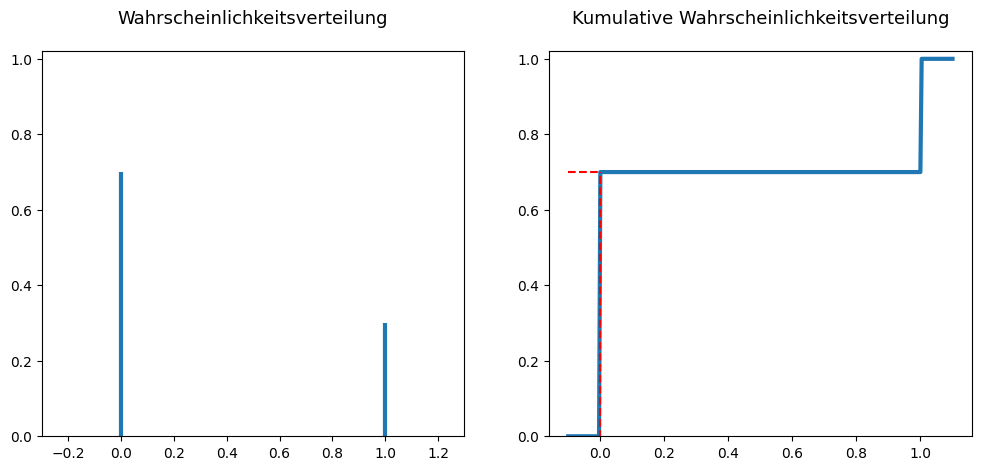

In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.array([0,1]),0,X_pmf,lw=3)
ax1 = plt.xlim(-0.3,1.3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,1.1,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,0,color="red",linestyle="dashed")
ax2 = plt.vlines(0,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [21]:
X.mean()

0.3

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [22]:
X.std()

0.458257569495584

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [24]:
X.ppf(0.7)

0.0

- Berechnen Sie in Abhängigkeit von $p$ formal den Erwartungswert $\mu$, die Standardabweichung $\sigma$.

Aus der Wahrscheinlichkeitsverteilung der Bernoulli Verteilung
$$\begin{array}{c|cc}x&\quad 0 \quad & \quad 1 \quad\\ \hline P(X= x)&1-p&p\end{array}$$ 
finden wir allgemein den **Erwartungswert**

$$\begin{align*}\pmb{\mu} \;&=\; 
P(X=0)\cdot 0 + P(X=1) \cdot 1\\ 
&\;=\; (1-p)\cdot 0 + p \cdot 1 \rule{0cm}{0.75cm}\\
&\;=\; \pmb{p} \rule{0cm}{0.75cm}\end{align*}$$

und für die **Varianz**

$$\begin{align*}\pmb{\sigma}^2 \;&=\; 
P(X=0)\cdot (0-\pmb{\mu})^2 + P(X=1) \cdot (1-\pmb{\mu})^2\\ 
&\;=\; (1-p)\cdot(0-\pmb{p})^2 + p \cdot(1-\pmb{p})^2 \rule{0cm}{0.75cm}\\
&\;=\; (1-p)\cdot p\cdot\big(p + (1-p)\big) \rule{0cm}{0.75cm}\\
&\;=\; \pmb{(1-p)\cdot p} \rule{0cm}{0.75cm}\end{align*}$$

also für die **Standardabweichung**

$$\pmb{\sigma} =  \pmb{\sqrt{(1-p)\cdot p}} \quad.$$

- Suchen Sie typische Beispiele für Zufallsvariablen, die Bernoulli verteilt sind.

#### Beispiele
- Münzwurf 
- Prüfen, ob eine Nachricht fehlerhaft ist
- Akzeptieren oder Ablehnen einer Kreditkarten-Zahlung
- Bestehen oder Durchfallen einer Prüfung
- Treffer oder Fehlschuss in einem Spiel
- Aktivierung eines Sensors oder Fehlalarm
- Binäre Entscheidung in einem Algorithmus
- Bit in einem Datenstrom (1 oder 0)
- Fehlererkennung in einem Computerprogramm
- Erfolgreiche oder fehlgeschlagene Login-Versuche
- Aktivierung eines Neurons in einem neuronalen Netzwerk
- Anklicken eines Elements auf einer Webseite oder nicht

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Binomial Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus der Menge $\{0,1,\ldots,n\}$ hat eine **Binomialverteilung** mit: $$P(X=k)=\binom{n}{k}\cdot p^k\cdot(1-p)^{n-k}$$
- Wenn eine *diskrete* Zufallsvariable $X$ **Binomial** verteilt ist, schreiben wir $$X\sim \mathsf{Bin}(p,n)\;.$$
- In **SciPy** heisst diese Zufallsvariable **binom( )** und sie hat zwei Parameter <tt>n</tt> und <tt>p</tt>.
- ***Zum Beispiel*** die Anzahl Köpfe bei $n$ Würfen mit einer gefälschten Münze.

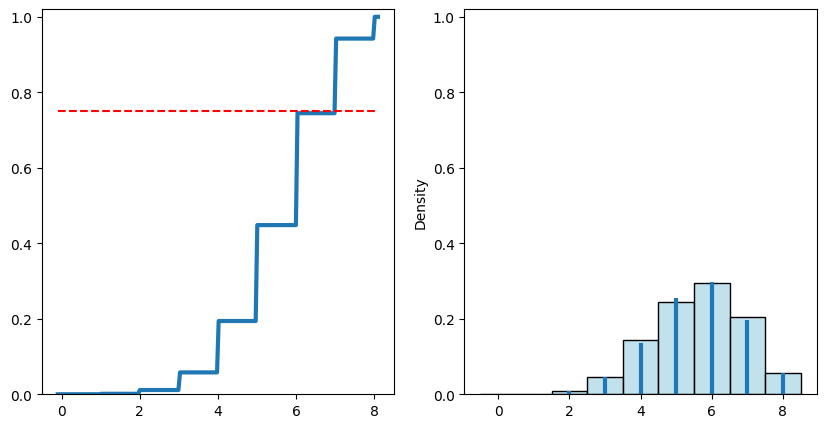

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import binom

#Zufallsvariable definieren
X = binom(p=0.7,n=8)

#Cumulative Distribution Function
x = np.linspace(-0.1,8.1,200)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.arange(0,9))

#5000 zufällige Werte ziehen:
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,8.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(-0.5,9.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.arange(0,9),0,X_pmf,lw=3)
ax2 = plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [24]:
X.ppf(0.75)

7.0

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [ ]:
X.mean()

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [ ]:
X.var()

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [ ]:
X.std()

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Mit pmf:
X.pmf(3) + X.pmf(4) 

In [ ]:
# Mit cdf:
X.cdf(4) - X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 3</span>
Definieren Sie eine Zufallsvariable $X$, die mit $p=0.75$ und $n=12$ Binomial verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(3\leqslant X \leqslant 9)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Binomial verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Binomialverteilung** für $\,\pmb{p=0.75}\,$ und $\,\pmb{n=12}\,$:

In [25]:
from scipy.stats import binom

X = binom(p=0.75,n=12)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [37]:
import numpy as np

X_pmf = X.pmf(np.arange(0,13))
X_cdf = X.cdf(np.linspace(-0.1,12.1,300))

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

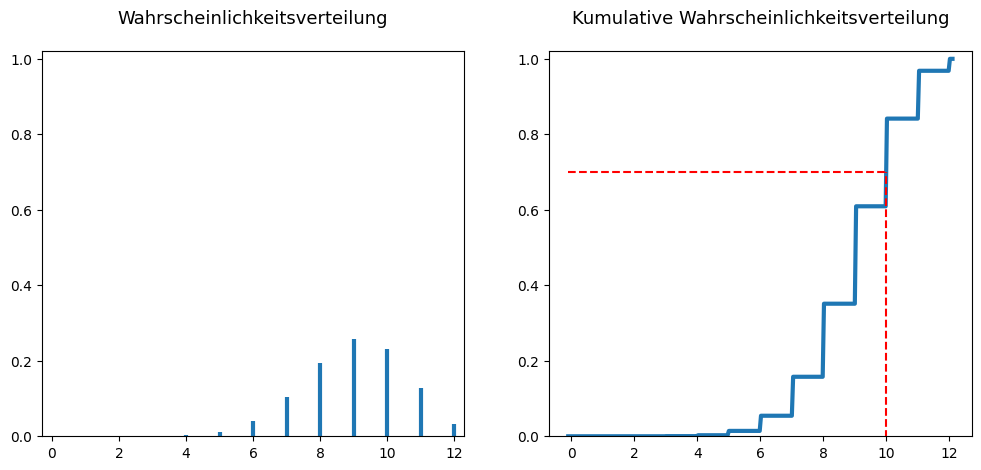

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.arange(0,13),0,X_pmf,lw=3)
ax1 = plt.xlim(-0.3,12.3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,12.1,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,10,color="red",linestyle="dashed")
ax2 = plt.vlines(10,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [30]:
X.mean()

9.0

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [31]:
X.std()

1.5

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [32]:
X.ppf(0.7)

10.0

- Wie gross ist die Wahrscheinlichkeit $P(3\leqslant X \leqslant 9)$? 

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [33]:
X.cdf(9) - X.cdf(2)

0.6092873811721802

Mit der ***Wahrscheinlichkeitsverteilung*** finden wir:

In [34]:
sum([X.pmf(i) for i in range(3,10)])

0.60928738117218

- Suchen Sie typische Beispiele für Zufallsvariablen, die Binomial verteilt sind.

#### Beispiele
- Anzahl der Köpfe beim mehrmaligen Münzwurf  
- Anzahl der Personen mit einem bestimmten Geburtsmonat
- Anzahl richtiger Antworten bei einem Multiple-Choice-Test
- Anzahl Klicks auf ein Element einer Webseite
- Anzahl erfolgreicher Paketübertragungen im Netzwerk
- Anzahl erfolgreicher Login-Versuche
- Fehlerrate in Speicherzellen
- Wirksamkeit eines Impfstoffs
- Anzahl von Patienten mit einer bestimmten Blutgruppe

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Geometrische Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus der Menge $\mathbb{N}_0=\{0,1,2,\ldots\}$ hat eine **Geometrische Verteilung** mit: $$P(X=k)=(1-p)^{k-1}\cdot p$$
- Wenn eine *diskrete* Zufallsvariable $X$ **Geometrisch** verteilt ist, schreiben wir $$X\sim \mathsf{Geo}(p)\;.$$
- In **SciPy** heisst diese Zufallsvariable **geom( )** und sie hat einen Parameter <tt>p</tt>.
- ***Zum Beispiel*** die Anzahl Würfe mit einer gefälschten Münze, bis zum ersten Mal Kopf erscheint.

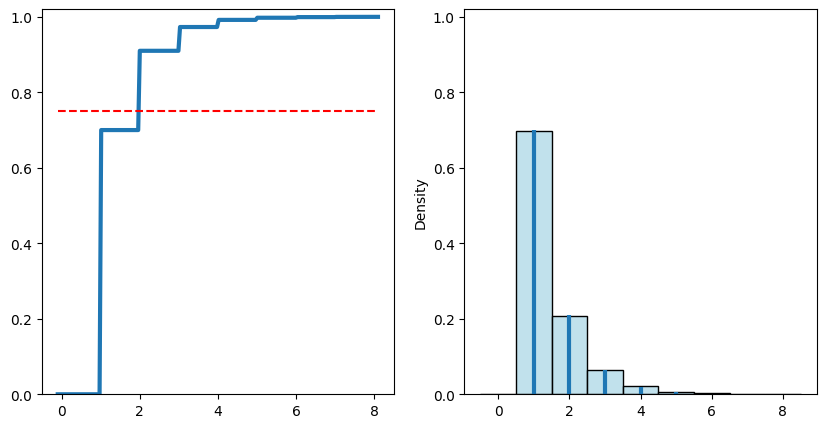

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import geom

#Zufallsvariable definieren
X = geom(p=0.7)

#Cumulative Distribution Function
x = np.linspace(-0.1,8.1,200)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.arange(0,9))

#5000 zufällige Werte ziehen:
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,8.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(-0.5,9.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.arange(0,9),0,X_pmf,lw=3)
ax2 = plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [ ]:
X.ppf(0.75)

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [ ]:
X.mean()

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:


In [ ]:
X.var()

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [ ]:
X.std()

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Mit pmf:
X.pmf(3) + X.pmf(4)

In [ ]:
# Mit cdf:
X.cdf(4) - X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 4</span>
Definieren Sie eine Zufallsvariable $X$, die mit $p=0.4$ Geometrisch verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(X \geqslant 5)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Geometrisch verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Geometrischer Verteilung** für $\,\pmb{p=0.4}\,$:

In [38]:
from scipy.stats import geom

X = geom(0.4)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [39]:
import numpy as np

X_pmf = X.pmf(np.arange(0,13))
X_cdf = X.cdf(np.linspace(-0.1,12.1,300))

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

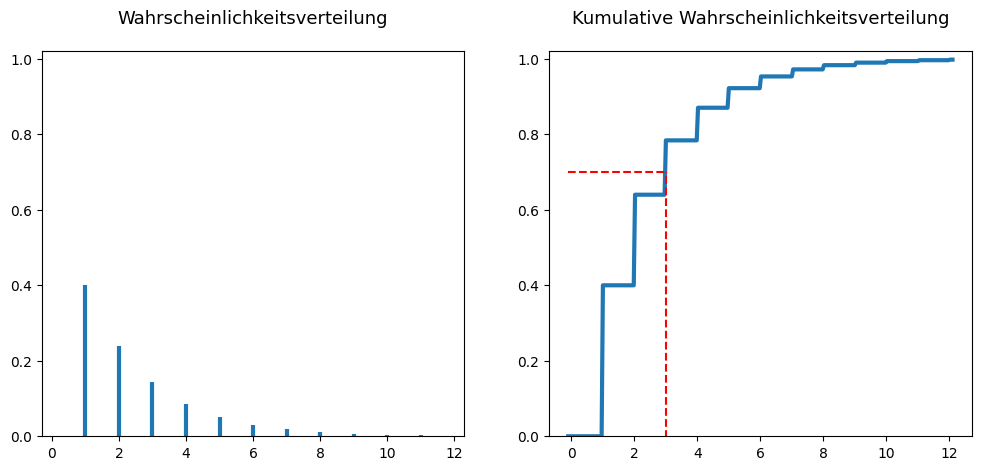

In [41]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.arange(0,13),0,X_pmf,lw=3)
ax1 = plt.xlim(-0.3,12.3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,12.1,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,3,color="red",linestyle="dashed")
ax2 = plt.vlines(3,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [42]:
X.mean()

2.5

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [43]:
X.std()

1.9364916731037083

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [44]:
X.ppf(0.7)

3.0

- Wie gross ist die Wahrscheinlichkeit $P(X \geqslant 5)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [45]:
1 - X.cdf(4)

0.12959999999999994

Mit der ***Wahrscheinlichkeitsverteilung*** finden wir:

In [46]:
1 - sum([X.pmf(i) for i in range(0,5)])

0.12959999999999994

- Suchen Sie typische Beispiele für Zufallsvariablen, die Geometrisch verteilt sind.

#### Beispiele
- Anzahl der Übertragungsversuche in Netzwerkprotokollen, bis ein Paket erfolgreich gesendet wird.
- Anzahl der Wiederholungen, bis ein randomisierter Algorithmus ein korrektes Ergebnis liefert.
- Anzahl der Wiederholungen bei fehlerhaften Übertragungen oder fehlgeschlagenen Operationen (Retransmissions in TCP oder Cloud-Systemen).
- Anzahl der Kollisionen beim Hashing (Open Addressing), bis ein freier Platz gefunden wird.
- Modellierung der Tiefe oder Anzahl der Schritte bis zum Auffinden eines bestimmten Knotens in zufälligen Bäumen.
- Wartezeit bis zum ersten Ereignis in Ereignissimulationen (Ankunft eines Jobs oder Fehlers).
- In der Qualitätskontrolle die Anzahl produzierter Teile, bis zum ersten fehlerhaften Produkt.
- In der Finanzmathematik die Anzahl Tage oder Transaktionen bis zum ersten Ausfall.
- In der Medizin die Anzahl der Behandlungen oder Tests bis zum ersten Erfolg.
- In der Lernforschung die Anzahl von Versuchen, bis eine Person eine Aufgabe korrekt löst.
- Im Marketing die Anzahl der Kontakte oder Werbeversuche, bis ein Kunde reagiert oder kauft.

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Poisson Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus der Menge $\mathbb{N}_0=\{0,1,2,\ldots\}$ hat eine **Poisson Verteilung** mit: $$P(X=k)=e^{-\mu}\cdot\frac{\mu^k}{k!}$$
- Wenn eine *diskrete* Zufallsvariable $X$ **Poisson** verteilt ist, schreiben wir $$X\sim \mathsf{Poi}(\mu)\;.$$
- In **SciPy** heisst diese Zufallsvariable **poisson( )** und sie hat einen Parameter <tt>$\mu$</tt>.
- ***Zum Beispiel*** die Anzahl Anrufe pro Stunde in einem Call-Center.


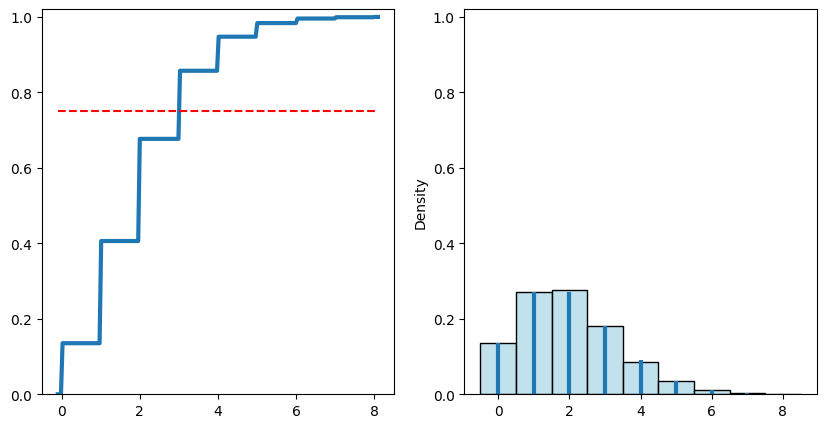

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson

#Zufallsvariable definieren
X = poisson(mu=2)

#Cumulative Distribution Function
x = np.linspace(-0.1,8.1,200)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.arange(0,9))

#5000 zufällige Werte ziehen:
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,8.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(-0.5,9.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.arange(0,9),0,X_pmf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:


In [ ]:
X.ppf(0.75)

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [ ]:
X.mean() # ist gleich dem Parameter mu

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [ ]:
X.var() # ist gleich dem Parameter mu

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [ ]:
X.std()

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Mit pmf:
X.pmf(3) + X.pmf(4)

In [ ]:
# Mit cdf:
X.cdf(4) - X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 5</span>
Definieren Sie eine Zufallsvariable $X$, die mit $\mu=4.25$ Poisson verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(X \geqslant 5)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Poisson verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Poissonverteilung** für $\,\pmb{\mu=4.25}\,$:

In [47]:
from scipy.stats import poisson

X = poisson(mu=4.25)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [48]:
X_pmf = X.pmf(np.arange(0,13))
X_cdf = X.cdf(np.linspace(-0.1,12.1,300))

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

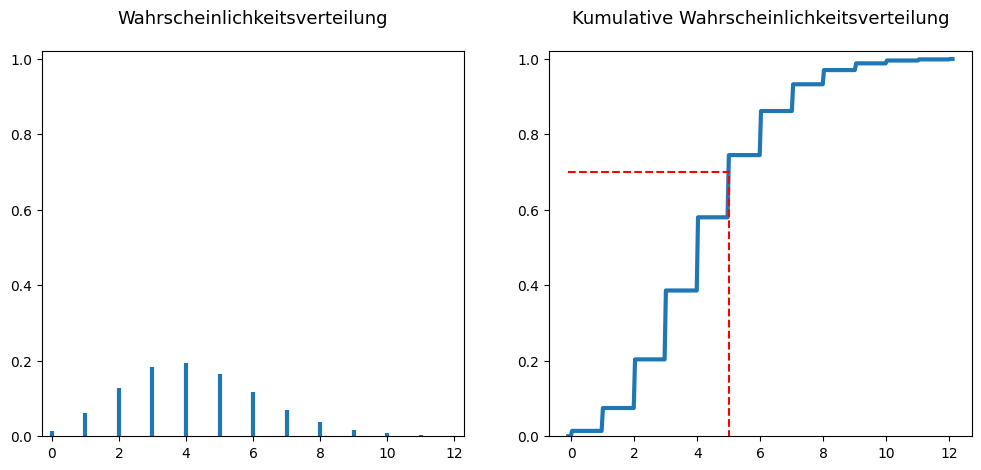

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.arange(0,13),0,X_pmf,lw=3)
ax1 = plt.xlim(-0.3,12.3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,12.1,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,5,color="red",linestyle="dashed")
ax2 = plt.vlines(5,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [50]:
X.mean()

4.25

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [51]:
X.std()

2.0615528128088303

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [52]:
X.ppf(0.7)

5.0

- Wie gross ist die Wahrscheinlichkeit $P(X \geqslant 5)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [53]:
1 - X.cdf(4)

0.419881686272238

Mit der ***Wahrscheinlichkeitsverteilung*** finden wir:

In [54]:
1 - sum([X.pmf(i) for i in range(0,5)])

0.419881686272238

- Suchen Sie typische Beispiele für Zufallsvariablen, die Poisson verteilt sind.

#### Beispiele
- Anzahl Zerfälle pro Sekunde in einer Menge radioaktiven Materials
- Anzahl Autos, die eine Ampel in einer bestimmten Zeitspanne passieren
- Anzahl Flugzeuge, die innerhalb einer Stunde auf einem Flughafen landen
- Anzahl Einbrüchen oder Verkehrsunfällen in einer bestimmten Stadt pro Monat
- Anzahl Tippfehlern in einem Text
- Anzahl Büchern, die pro Tag in einer Bibliothek ausgeliehen werden
- Mutationsrate von Genen pro Generation
- Anzahl Kunden, die pro Stunde an einem Geldautomaten Geld abheben
- Poisson-Rauschen in Kameraaufnahmen mit schwachem Licht
- Häufigkeit von Fehlern in einem Softwaresystem
- Anzahl Angriffe auf ein System (z.B. DDoS-Angriffe pro Minute) 

$\qquad\vdots$


### <span style="color:rgb(160,0,86)">Die Hypergeometrische Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit zulässigen Werten aus der Menge $\mathbb{N}_0=\{0,1,2,\ldots\}$ hat eine **Hypergeometrische Verteilung** mit: $$P(X=k)=\frac{\binom{n}{k}\cdot\binom{M-n}{N-k}}{\binom{M}{N}}$$
- Wenn eine *diskrete* Zufallsvariable $X$ **Hypergeometrisch** verteilt ist, schreiben wir $$X\sim \mathsf{HypG}(M,n,N)\;.$$
- In **SciPy** heisst diese Zufallsvariable **hypergeom( )** und sie hat drei Parameter <tt>M</tt>, <tt>n</tt> und <tt>N</tt>.
- ***Zum Beispiel*** die Anzahl weisse Kugeln in einer Auswahl von $N$ Kugeln. Diese $N$ Kugeln werden aus einer Urne mit insgesamt $M$ Kugeln gezogen, von denen total $n$ weiss sind.

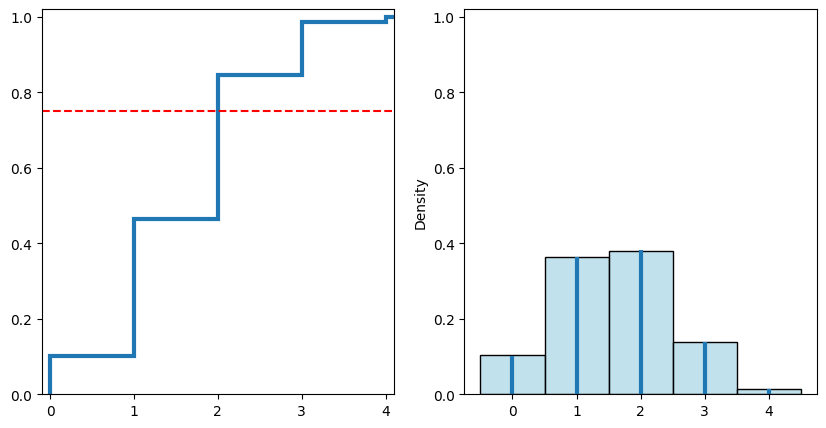

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import hypergeom

#Zufallsvariable definieren
# M=20 Kugeln, davon n=4 weiss und 16 schwarz, N=8 Kugeln werden zufällig gezogen
X = hypergeom(M=20,n=4,N=8) 

#Cumulative Distribution Function
x = np.arange(0,5)
X_cdf = X.cdf(x)

#Probability Mass Function
X_pmf = X.pmf(np.arange(0,5))

# 5000 zufällige Werte ziehen
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.stairs(X_cdf,orientation="vertical",lw=3)
plt.ylim(0,1.02)
plt.xlim(-0.1,4.1)
ax1.hlines(0.75,-0.1,4.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,bins=np.arange(-0.5,5.5),stat="density",color="lightblue",ax=ax2)
ax2.vlines(np.array([0,1,2,3,4]),0,X_pmf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [ ]:
X.ppf(0.75)

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [ ]:
X.mean()

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [ ]:
X.var()

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [ ]:
X.std()

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Mit pmf:
X.pmf(3) + X.pmf(4)

In [ ]:
# Mit cdf:
X.cdf(4) - X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 6</span>
Definieren Sie eine Zufallsvariable $X$, die mit $M=50$, $n=6$, $N=30$ Hypergeometrisch verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 2)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Hypergeometrisch verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsverteilung und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Hypergeometrischer Verteilung** für $\,\pmb{M=50}\,$, $\,\pmb{n=6}\,$ und $\,\pmb{N=30}\,$

In [55]:
from scipy.stats import hypergeom

X = hypergeom(M=50,n=6,N=30)

Wir berechnen mit der *Probability Mass Function* **pmf( )** die ***Wahrscheinlichkeitsverteilung*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [56]:
X_pmf = X.pmf(np.arange(0,7))
X_cdf = X.cdf(np.arange(0,7)) # cdf() bei hypergoem ist nur für int definiert!

Nun können wir die ***Wahrscheinlichkeitsverteilungen*** <tt>X_pmf</tt> mit der Funktion **plt.vlines( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion <span style="color: red;">**plt.stairs( )**</span> zeichnen:

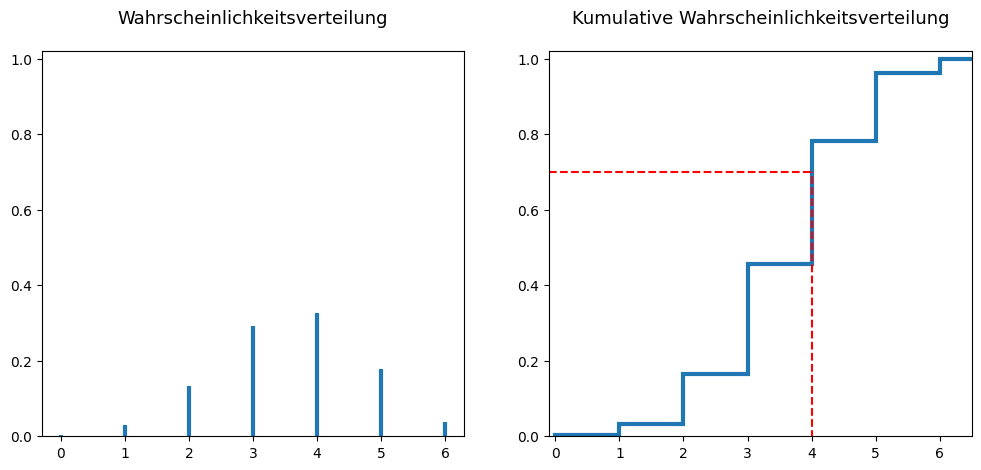

In [57]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.vlines(np.arange(0,7),0,X_pmf,lw=3)
ax1 = plt.xlim(-0.3,6.3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.stairs(X_cdf,orientation="vertical",lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.xlim(-0.1,6.5)
ax2 = plt.hlines(0.7,-0.1,4,color="red",linestyle="dashed")
ax2 = plt.vlines(4,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [58]:
X.mean()

3.6

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [59]:
X.std()

1.1371284995504227

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [61]:
X.ppf(0.7)

4.0

- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 2)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [62]:
X.cdf(2)

0.16433857539315452

Mit der ***Wahrscheinlichkeitsverteilung*** finden wir:

In [63]:
X.pmf(0) + X.pmf(1) + X.pmf(2)

0.16433857539315452

- Suchen Sie typische Beispiele für Zufallsvariablen, die Hypergeometrisch verteilt sind.

#### Beispiele
- Anzahl Asse in einem 5-Karten-Pokerblatt
- Anzahl Defekte Chips oder Transistoren in einer elektronischen Baugruppe  
- Anzahl richtig getippter Zahl beim Lotto
- Anzahl Infizierter Personen in der Stichprobe
- Anzahl einer bestimmten Meinung von Befragten
- Anzahl Individuen einer bestimmten Art in einer zufälligen Stichprobe aus einer Population
- Häufigkeit einer bestimmte Eigenschaften in einer begrenzten Anzahl von Elementen aus einer Datenbank oder einem Speicher

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die stetige uniforme Verteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus dem Intervall $[\texttt{loc},\texttt{loc}+\texttt{scale}]$ hat eine **stetige uniforme Verteilung** mit: $$P(X\leqslant x)=\int\limits_{\texttt{loc}}^{x}\frac{1}{\texttt{scale}}\,dt$$
- Wenn ein Zufallsvariable $X$ **stetig uniform** verteilt ist, schreiben wir $$X\sim \mathsf{Uni}(\text{loc},\text{scale})\;.$$
- In **SciPy** heisst diese Zufallsvariable **uniform( )** und sie hat zwei Parameter <tt>loc</tt> und <tt>scale</tt>.
- ***Zum Beispiel*** zufällig eine reelle Zahl zwischen Null und Eins wählen.


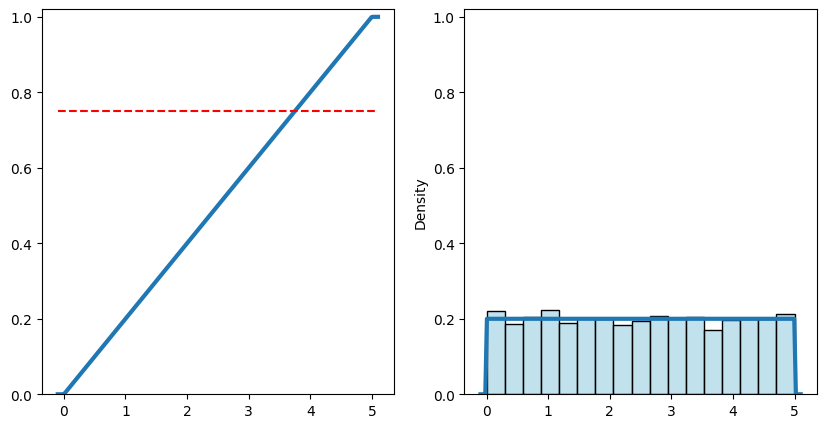

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import uniform

#Zufallsvariable definieren
X = uniform(loc=0,scale=5)

#Cumulative Distribution Function
x = np.linspace(-0.1,5.1,200)
X_cdf = X.cdf(x)

#Probability Density Function (statt pmf bei diskreten ZV)
X_pdf = X.pdf(x)

#5000 zufällige Werte
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,5.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,stat="density",color="lightblue",ax=ax2)
ax2.plot(x,X_pdf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [13]:
X.ppf(0.75)

3.75

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:


In [14]:
X.mean()

2.5

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:


In [15]:
X.var()

2.083333333333333

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:


In [16]:
X.std()

1.4433756729740643

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [17]:
# Nur mit cdf:
X.cdf(5) - X.cdf(2)

0.6

### <span style="color:rgb(160,0,86)">Aufgabe 7</span>
Definieren Sie eine Zufallsvariable $X$, die auf dem Intervall $[3,7]$ stetig uniform verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 4.33)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die stetig uniform verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit stetiger uniformer Verteilung** auf dem Intervall $\,\pmb{[3,7]}\,$

In [64]:
from scipy.stats import uniform
 
X = uniform(loc=3,scale=4)

Wir berechnen mit der *Probability Density Function* **pdf( )** die ***Wahrscheinlichkeitsdichte*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [65]:
X_pdf = X.pdf(np.linspace(-0.1,7.8,300))
X_cdf = X.cdf(np.linspace(-0.1,7.8,300))

Nun können wir die ***Wahrscheinlichkeitsdichte*** <tt>X_pdf</tt> mit der Funktion **plt.plot( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

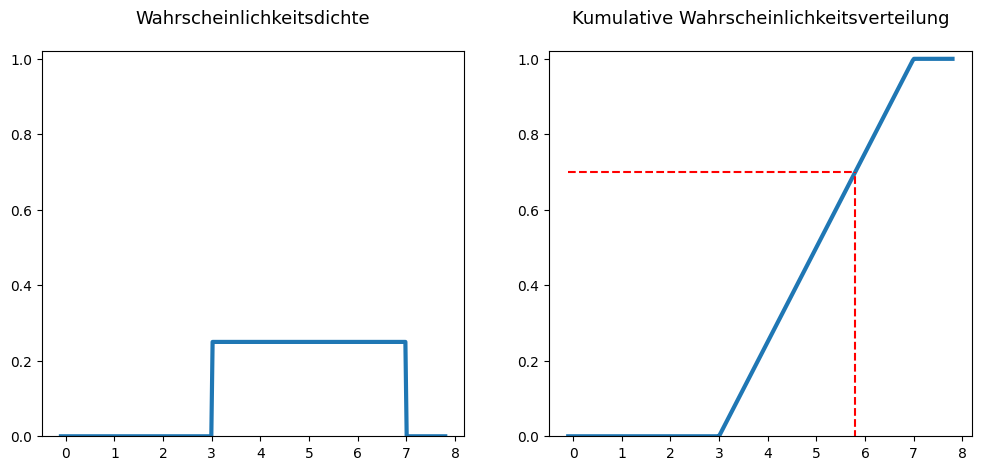

In [67]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.plot(np.linspace(-0.1,7.8,300),X_pdf,lw=3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsdichte",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,7.8,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,5.8,color="red",linestyle="dashed")
ax2 = plt.vlines(5.8,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [68]:
X.mean()

5.0

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [69]:
X.std()

1.1547005383792515

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [70]:
X.ppf(0.7)

5.8

- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 4.33)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [71]:
X.cdf(4.33)

0.3325

- Suchen Sie typische Beispiele für Zufallsvariablen, die stetig uniform verteilt sind.

#### Beispiele
- Viele Programmiersprachen nutzen die uniforme Verteilung zur Erzeugung von Zufallszahlen zwischen 0 und 1
- In numerischen Berechnungen zur Modellierung physikalischer Prozesse  
- Zufällige Auswahl von Elementen in Algorithmen (Quicksort, Hashfunktionen, etc.)
- Gleichmässige Platzierung von Objekten oder zufällige Bewegungen von Charakteren in Computerspielen
- Zufälliges Rauschen in Messgeräten, wenn keine Werte bevorzugt entstehen 
- Zufällige Ankunftszeiten von Kunden oder Ereignissen
- Preisänderungen in einfachen Modellen für Aktienkurse
- Erzeugung sicherer Schlüssel in kryptografischen Algorithmen
- Salt-Werte in Hashfunktionen, um Passwort-Hashes zu schützen

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Exponentialverteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus dem Intervall $[\texttt{loc},\infty)$ hat eine **Exponentialverteilung** mit: $$P(X\leqslant x)=\int\limits_{\texttt{loc}}^{x}\frac{1}{\texttt{scale}}\cdot e^{-\frac{t-\texttt{loc}}{\texttt{scale}}}\,dt$$
- Wenn ein *stetige* Zufallsvariable $X$ **Expenential** verteilt ist, schreiben wir $$X\sim \mathsf{Exp}(\text{loc},\text{scale})\;.$$
- In **SciPy** heisst diese Zufallsvariable **expon( )** und sie hat zwei Parameter <tt>loc</tt> und <tt>scale</tt>.
- ***Zum Beispiel*** die Lebensdauer einer Glühbirne

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import expon

#Zufallsvariable definieren
X = expon(loc=1,scale=2)

#Cumulative Distribution Function
x = np.linspace(-0.1,15.1,200)
X_cdf = X.cdf(x)

#Probability Density Function
X_pdf = X.pdf(x)

#5000 zufällige Werte
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-0.1,15.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,stat="density",color="lightblue",ax=ax2)
ax2.plot(x,X_pdf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [ ]:
X.ppf(0.75)

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [ ]:
X.mean()

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [ ]:
X.var()

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:


In [ ]:
X.std()

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Nur mit cdf:
X.cdf(5)- X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 8</span>
Definieren Sie eine Zufallsvariable $X$, die mit $\text{loc}=2$ und $\text{scale}=5$ Exponential verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 6)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Exponential verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Exponentialverteilung** für $\text{loc}=2$ und $\text{scale}=5$

In [72]:
from scipy.stats import expon

X = expon(loc=2,scale=5)

Wir berechnen mit der *Probability Density Function* **pdf( )** die ***Wahrscheinlichkeitsdichte*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [73]:
X_pdf = X.pdf(np.linspace(-0.1,25,300))
X_cdf = X.cdf(np.linspace(-0.1,25,300))

Nun können wir die ***Wahrscheinlichkeitsdichte*** <tt>X_pdf</tt> mit der Funktion **plt.plot( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

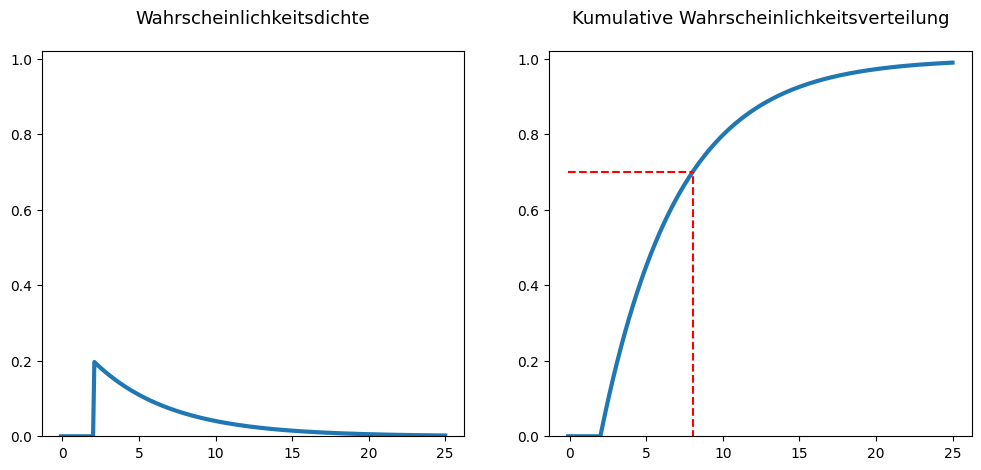

In [74]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.plot(np.linspace(-0.1,25,300),X_pdf,lw=3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsdichte",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-0.1,25,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-0.1,8.01986,color="red",linestyle="dashed")
ax2 = plt.vlines(8.01986,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [75]:
X.mean()

7.0

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [76]:
X.std()

5.0

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [78]:
X.ppf(0.7)

8.01986402162968

- Wie gross ist die Wahrscheinlichkeit $P(X \leqslant 6)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [79]:
X.cdf(6)

0.5506710358827784

- Suchen Sie typische Beispiele für Zufallsvariablen, die Exponential verteilt sind.

#### Beispiele
- Die Zeit zwischen zwei Anrufen oder Anfragen in Callcentern, Supermärkten oder Webservern
- Wartezeiten in Systemen mit zufälligen Verzögerungen, etwa beim Datenabruf aus einem Cache oder einer Datenbank  
- Zeit bis zum Versagen eines Geräts in der Fertigungstechnik 
- Mittlere Ausfallzeit in Systeme, insbesondere elektronische oder mechanische Bauteile
- Zeit bis zum nächsten Software-Fehler in IT-Systemen, wenn Fehler zufällig auftreten
- Zeit bis zum Zerfall eines radioaktiven Atoms
- Zeit zwischen Meteoriteneinschlägen oder Erdbeben in bestimmten Regionen
- Zeit zwischen zwei grossen Preisschwankungen an der Börse 
- Zeit bis ein Kunde eine erneute Transaktion tätigt oder sich aus einem Service abmeldet
- Zeit zwischen Mutationen in der DNA (Genetik)
- Zeit bis zur nächsten Infektion oder die Zeit bis zur Heilung
- Zeit bis zum Tod oder zur Genesung in einer Epidemie
- Zeit bis zum nächsten Unfall in der Verkehrsstatistik
- Zeit bis zum nächsten Cyberangriff auf ein System

$\qquad\vdots$

***

### <span style="color:rgb(160,0,86)">Die Normalverteilung</span>

- Eine Zufallsvariable $\,\pmb{X}\,$ mit Werten aus $\mathbb{R}$ hat eine **Normalverteilung** mit: $$P(X\leqslant x)=\int\limits_{-\infty}^{x}\frac{1}{\texttt{scale}\cdot\sqrt{2\pi}}\cdot e^{-\frac{(t-\texttt{loc})^2}{2\,\cdot\,\texttt{scale}^2}}\,dt$$
- Wenn ein *stetige* Zufallsvariable $X$ **normal** verteilt ist, schreiben wir $$X\sim \mathsf{Norm}(\text{loc},\text{scale})\;.$$
- In **SciPy** heisst diese Zufallsvariable **norm( )** und sie hat zwei Parameter <tt>loc</tt> und <tt>scale</tt>.
- ***Zum Beispiel*** die Körpergrösse von Menschen.

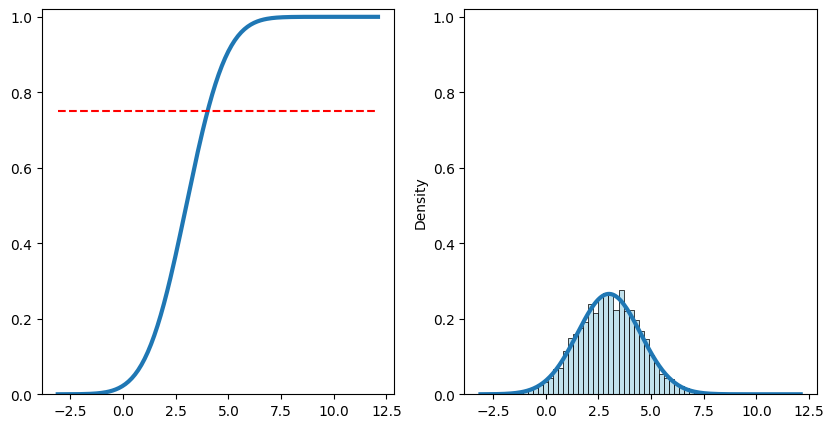

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

#Zufallsvariable definieren
X = norm(loc=3,scale=1.5)

#Cumulative Distribution Function
x = np.linspace(-3.1,12.1,200)
X_cdf = X.cdf(x)

#Probability Density Function
X_pdf = X.pdf(x)

#5000 zufällige Werte
sample = X.rvs(size=5000)

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(x,X_cdf,lw=3)
plt.ylim(0,1.02)
ax1.hlines(0.75,-3.1,12.1,color="red",linestyle="dashed")

ax2 = fig.add_subplot(1,2,2)
sns.histplot(sample,stat="density",color="lightblue",ax=ax2)
ax2.plot(x,X_pdf,lw=3)
plt.ylim(0,1.02)

plt.show()

Das **0.75-Quantil** $\,\pmb{x_{0.75}}\,$ ist:

In [ ]:
X.ppf(0.75)

Der **Erwartungswert** $\,\pmb{\mu}\,$ ist:

In [29]:
X.mean()

3.0

Die **Varianz** $\,\pmb{\sigma^2}\,$ ist:

In [ ]:
X.var()

Die **Standardabweichung** $\,\pmb{\sigma}\,$ ist:

In [30]:
X.std()

1.5

Die **Wahrscheinlichkeit** $\,\pmb{P(2<X<5)}\,$ ist:

In [ ]:
# Nur mit cdf:
X.cdf(5) - X.cdf(2)

### <span style="color:rgb(160,0,86)">Aufgabe 9</span>
Definieren Sie eine Zufallsvariable $X$, die mit $\text{loc}=-3$ und $\text{scale}=3.5$ Normal verteilt ist.
- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.
- Sie verändern die Parameter $\text{loc}$ und $\text{scale}$ die Wahrscheinlichkeitsverteilung? 
- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.
- Wie gross ist die Wahrscheinlichkeit $P(-4\leqslant X \leqslant -1)$? 
- Suchen Sie typische Beispiele für Zufallsvariablen, die Normal verteilt sind.

***

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

- Zeichnen Sie die Wahrscheinlichkeitsdichte und die kumulative Wahrscheinlichkeitsverteilung.

Wir definieren eine **Zufallsvariabel mit Normalverteilung** für $\text{loc}=-3$ und $\text{scale}=3.5$

In [80]:
from scipy.stats import norm

X = norm(loc=-3,scale=3.5)

Wir berechnen mit der *Probability Density Function* **pdf( )** die ***Wahrscheinlichkeitsdichte*** und mit der *Cumulative Distribution Function* **cdf( )** die ***kumulative Wahrscheinlichkeitsverteilung***:

In [81]:
X_pdf = X.pdf(np.linspace(-13,7,300))
X_cdf = X.cdf(np.linspace(-13,7,300))

Nun können wir die ***Wahrscheinlichkeitsdichte*** <tt>X_pdf</tt> mit der Funktion **plt.plot( )** und die ***kumulative Wahrscheinlichkeitsverteilung*** <tt>X_cdf</tt> mit der Funktion **plt.plot( )** zeichnen:

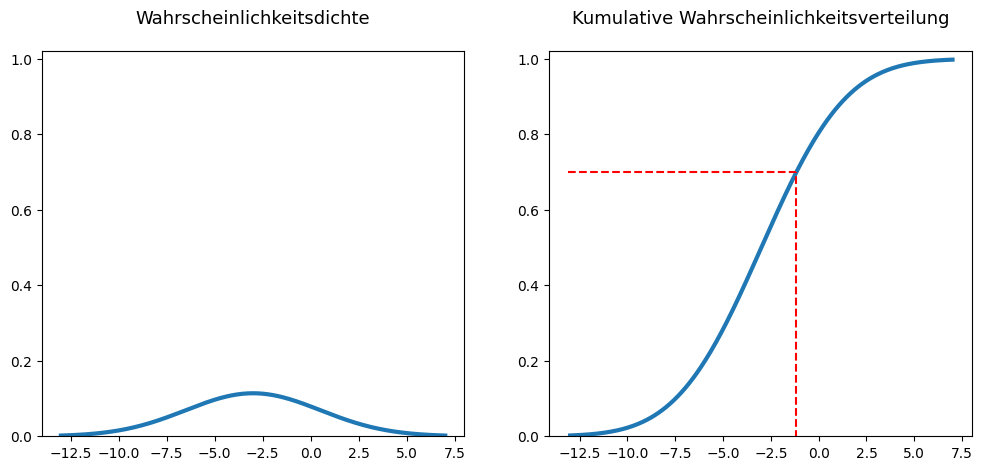

In [82]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1 = plt.plot(np.linspace(-13,7,300),X_pdf,lw=3)
ax1 = plt.ylim(0,1.02)
ax1 = plt.title("Wahrscheinlichkeitsdichte",fontsize=13,pad=20)

ax2 = fig.add_subplot(1,2,2)
ax2 = plt.plot(np.linspace(-13,7,300),X_cdf,lw=3)
ax2 = plt.ylim(0,1.02)
ax2 = plt.hlines(0.7,-13.1,-1.164598,color="red",linestyle="dashed")
ax2 = plt.vlines(-1.164598,-0.1,0.7,color="red",linestyle="dashed")
ax2 = plt.title("Kumulative Wahrscheinlichkeitsverteilung",fontsize=13,pad=20)

plt.show()

- Bestimmen Sie den Erwartungswert $\mu$, die Standardabweichung $\sigma$ und das 70\%-Quantil.

Mit der Methode **mean( )** finden wir den **Erwartungswert**

In [83]:
X.mean()

-3.0

Mit der Methode **std( )** finden wir die **Standardabweichung**

In [85]:
X.std()

3.5

Mit der Methode **ppf( )** finden wir das **70%-Quantil**

In [86]:
X.ppf(0.7)

-1.1645982055218576

- Wie gross ist die Wahrscheinlichkeit $P(-4\leqslant X \leqslant -1)$?

Mit der ***kumulativen Wahrscheinlichkeitsverteilung*** finden wir:

In [87]:
X.cdf(-1) - X.cdf(-4)

0.3285969358033314

- Suchen Sie typische Beispiele für Zufallsvariablen, die Normal verteilt sind.

#### Beispiele
- Messfehler und Unsicherheiten in Experimenten der Physik und Ingenieurwissenschaft
- Rauschen in natürliche Signale (z.B. in elektrischen Schaltkreisen)
- Variabilität in der Festigkeit von Materialien oder in der Lebensdauer von Produkten
- IQ-Werte sind in der Bevölkerung mit einem Mittelwert von ungefähr 100 und einer Standardabweichung von 15
- Grössen und Gewichte von Menschen in einer grossen Population
- Noten oder Testergebnisse in einer grossen Gruppe
- Preisbewegungen von Aktienkursen und Renditen an der Börse (in einfachen Modellen)
- Lohnentwicklungen innerhalb einer homogener Gruppe (Einkommen sind im Allgemeinen eher schief verteilt)
- Fehler in Wirtschaftsprognosen und Vorhersagen
- Viele physiologische Merkmale in der Medizin wie Blutdruck- und Cholesterinwerte
- Die Zeit, die ein Mensch benötigt, um auf einen Reiz zu reagieren (Reaktionszeiten)
- Merkmale wie Lebensdauer oder Zellwachstum (wegen vieler genetischen und umweltbedingten Einflüsse)
- Viele Machine-Learning-Algorithmen setzen normalverteilte Daten voraus (z.B. lineare Regression, Gaussian Naive Bayes)
- In Computer Vision wird normales Rauschen in Bildern (Bildverarbeitung) oft mit einer Normalverteilung modelliert.
- Die Verteilung der Laufzeiten von Algorithmen oder die Antwortzeiten von Servern kann sich einer Normalverteilung annähern (Performance-Analysen)
- Die Verteilung der Fahrzeiten auf einer Strecke ohne Stau ist oft normalverteilt
- Fertigungsprozesse, bei denen viele kleine Faktoren eine Rolle spielen (z.B. Abweichungen in der Länge eines Bauteils), erzeugen normalverteilte Messwerte     

$\qquad\vdots$

***

![HSLU](Bilder/LogoHSLU.png)